In [4]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")

In [5]:
root_dir = Path.cwd()

if root_dir.name == "notebooks":
    root_dir = root_dir.parent

raw_dir = root_dir / "data" / "raw"

preferred_names = [
    "data.csv",
    "training.csv",
    "train.csv",
]

data_path = next(
    (raw_dir / name for name in preferred_names if (raw_dir / name).exists()),
    None,
)

if data_path is None:
    excluded_terms = ("test", "sample", "definition", "variable")
    candidates = [
        path
        for path in raw_dir.glob("*.csv")
        if not any(term in path.name.lower() for term in excluded_terms)
    ]

    if len(candidates) != 1:
        raise FileNotFoundError(
            "Could not identify one labeled transaction CSV. "
            f"CSV files found: {[path.name for path in raw_dir.glob('*.csv')]}"
        )

    data_path = candidates[0]

df = pd.read_csv(data_path)

print(f"Dataset: {data_path.relative_to(root_dir)}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Dataset: data\raw\data.csv
Rows: 95,662
Columns: 16


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,"1,000.0000",1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0000,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0000,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,"20,000.0000",21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0000,644,2018-11-15T03:34:21Z,2,0


In [6]:
expected_columns = {
    "TransactionId",
    "BatchId",
    "AccountId",
    "SubscriptionId",
    "CustomerId",
    "CurrencyCode",
    "CountryCode",
    "ProviderId",
    "ProductId",
    "ProductCategory",
    "ChannelId",
    "Amount",
    "Value",
    "TransactionStartTime",
    "PricingStrategy",
    "FraudResult",
}

missing_columns = expected_columns.difference(df.columns)
unexpected_columns = set(df.columns).difference(expected_columns)

if missing_columns:
    raise ValueError(f"Required columns missing: {sorted(missing_columns)}")

print("Schema validation passed.")
print(f"Unexpected columns: {sorted(unexpected_columns) or 'None'}")

display(
    pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing_count": df.isna().sum(),
            "missing_percentage": df.isna().mean().mul(100).round(4),
            "unique_values": df.nunique(dropna=False),
        }
    )
)

Schema validation passed.
Unexpected columns: None


,dtype,missing_count,missing_percentage,unique_values
TransactionId,str,0,0.0000,95662
BatchId,str,0,0.0000,94809
AccountId,str,0,0.0000,3633
SubscriptionId,str,0,0.0000,3627
CustomerId,str,0,0.0000,3742
CurrencyCode,str,0,0.0000,1
CountryCode,int64,0,0.0000,1
ProviderId,str,0,0.0000,6
ProductId,str,0,0.0000,23
ProductCategory,str,0,0.0000,9


In [8]:
audit_df = df.copy()

audit_df["TransactionStartTime"] = pd.to_datetime(
    audit_df["TransactionStartTime"],
    errors="coerce",
    utc=True,
)

duplicate_rows = int(audit_df.duplicated().sum())
duplicate_transaction_ids = int(
    audit_df["TransactionId"].duplicated().sum()
)
invalid_dates = int(audit_df["TransactionStartTime"].isna().sum())

constant_columns = [
    column
    for column in audit_df.columns
    if audit_df[column].nunique(dropna=False) <= 1
]

negative_amounts = int((audit_df["Amount"] < 0).sum())
zero_amounts = int((audit_df["Amount"] == 0).sum())

amount_value_mismatches = int(
    (
        ~np.isclose(
            audit_df["Amount"].abs(),
            audit_df["Value"],
            equal_nan=True,
        )
    ).sum()
)

transactions_per_customer = audit_df.groupby("CustomerId").size()

print("TASK 2 INITIAL DATA AUDIT")
print("-" * 72)
print(f"dataset: {data_path.name}")
print(f"rows: {len(audit_df):,}")
print(f"columns: {audit_df.shape[1]}")
print(f"unique_customers: {audit_df['CustomerId'].nunique():,}")
print(f"unique_transactions: {audit_df['TransactionId'].nunique():,}")
print(f"duplicate_rows: {duplicate_rows:,}")
print(f"duplicate_transaction_ids: {duplicate_transaction_ids:,}")
print(f"total_missing_values: {audit_df.isna().sum().sum():,}")
print(f"invalid_transaction_dates: {invalid_dates:,}")
print(f"minimum_date: {audit_df['TransactionStartTime'].min()}")
print(f"maximum_date: {audit_df['TransactionStartTime'].max()}")
print(f"negative_amount_rows: {negative_amounts:,}")
print(f"zero_amount_rows: {zero_amounts:,}")
print(f"amount_value_mismatches: {amount_value_mismatches:,}")
print(f"constant_columns: {constant_columns or 'None'}")
print(
    "transactions_per_customer: "
    f"min={transactions_per_customer.min():,}, "
    f"median={transactions_per_customer.median():,.1f}, "
    f"mean={transactions_per_customer.mean():,.2f}, "
    f"max={transactions_per_customer.max():,}"
)

if "FraudResult" in audit_df.columns:
    print("\nFraudResult distribution (context only—not credit default):")
    print(audit_df["FraudResult"].value_counts(dropna=False).sort_index())

TASK 2 INITIAL DATA AUDIT
------------------------------------------------------------------------
dataset: data.csv
rows: 95,662
columns: 16
unique_customers: 3,742
unique_transactions: 95,662
duplicate_rows: 0
duplicate_transaction_ids: 0
total_missing_values: 0
invalid_transaction_dates: 0
minimum_date: 2018-11-15 02:18:49+00:00
maximum_date: 2019-02-13 10:01:28+00:00
negative_amount_rows: 38,189
zero_amount_rows: 0
amount_value_mismatches: 2,565
constant_columns: ['CurrencyCode', 'CountryCode']
transactions_per_customer: min=1, median=7.0, mean=25.56, max=4,091

FraudResult distribution (context only—not credit default):
FraudResult
0    95469
1      193
Name: count, dtype: int64


In [9]:
numerical_columns = audit_df.select_dtypes(include=np.number).columns.tolist()

display(
    audit_df[numerical_columns]
    .describe()
    .T
    .rename_axis("feature")
)

,count,mean,std,min,25%,50%,75%,max
feature,,,,,,,,
CountryCode,"95,662.0000",256.0000,0.0000,256.0000,256.0000,256.0000,256.0000,256.0000
Amount,"95,662.0000","6,717.8464","123,306.7972","-1,000,000.0000",-50.0000,"1,000.0000","2,800.0000","9,880,000.0000"
Value,"95,662.0000","9,900.5839","123,122.0878",2.0000,275.0000,"1,000.0000","5,000.0000","9,880,000.0000"
PricingStrategy,"95,662.0000",2.2560,0.7329,0.0000,2.0000,2.0000,2.0000,4.0000
FraudResult,"95,662.0000",0.0020,0.0449,0.0000,0.0000,0.0000,0.0000,1.0000


In [10]:
eda_df = audit_df.copy()

eda_df["absolute_amount"] = eda_df["Amount"].abs()
eda_df["transaction_date"] = eda_df["TransactionStartTime"].dt.date
eda_df["transaction_month"] = (
    eda_df["TransactionStartTime"]
    .dt.to_period("M")
    .astype(str)
)
eda_df["transaction_hour"] = eda_df["TransactionStartTime"].dt.hour
eda_df["transaction_day"] = eda_df["TransactionStartTime"].dt.day
eda_df["transaction_weekday"] = (
    eda_df["TransactionStartTime"].dt.day_name()
)
eda_df["is_debit"] = (eda_df["Amount"] < 0).astype(int)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

print("EDA features created.")
display(
    eda_df[
        [
            "Amount",
            "Value",
            "absolute_amount",
            "transaction_month",
            "transaction_hour",
            "transaction_weekday",
            "is_debit",
        ]
    ].head()
)

EDA features created.


C:\Users\a00928253\AppData\Local\Temp\ipykernel_4000\237185158.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,Amount,Value,absolute_amount,transaction_month,transaction_hour,transaction_weekday,is_debit
0,"1,000.0000",1000,"1,000.0000",2018-11,2,Thursday,0
1,-20.0000,20,20.0000,2018-11,2,Thursday,1
2,500.0000,500,500.0000,2018-11,2,Thursday,0
3,"20,000.0000",21800,"20,000.0000",2018-11,3,Thursday,0
4,-644.0000,644,644.0000,2018-11,3,Thursday,1


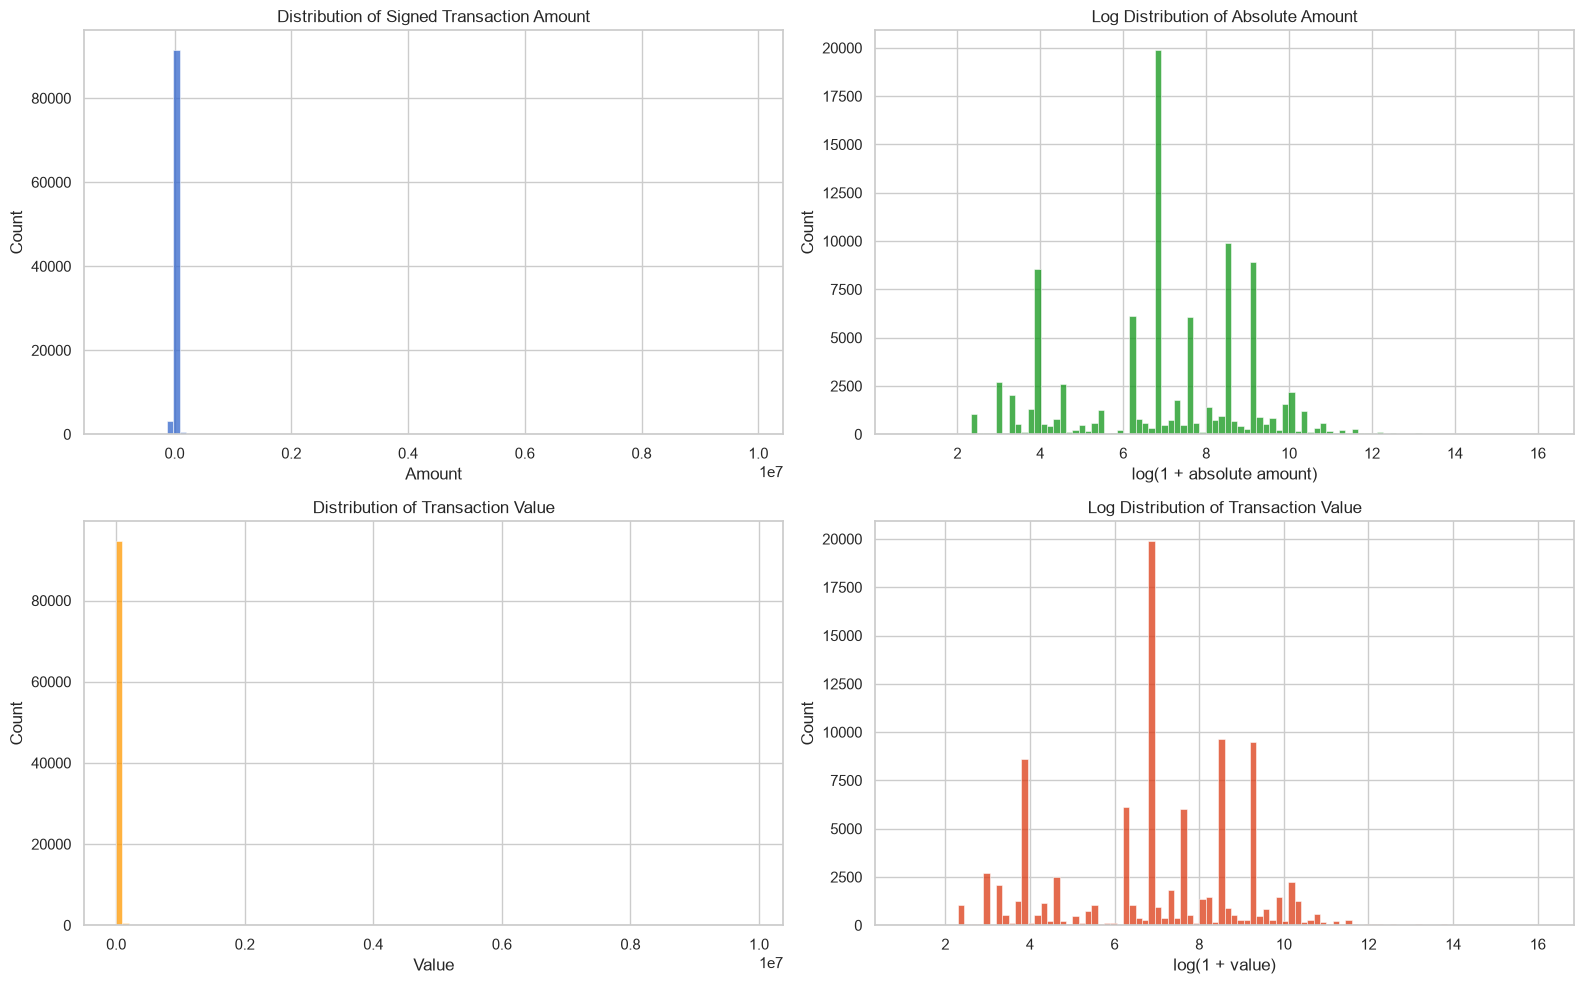

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(
    data=eda_df,
    x="Amount",
    bins=100,
    ax=axes[0, 0],
    color="#3366CC",
)
axes[0, 0].set_title("Distribution of Signed Transaction Amount")
axes[0, 0].set_xlabel("Amount")

sns.histplot(
    np.log1p(eda_df["absolute_amount"]),
    bins=100,
    ax=axes[0, 1],
    color="#109618",
)
axes[0, 1].set_title("Log Distribution of Absolute Amount")
axes[0, 1].set_xlabel("log(1 + absolute amount)")

sns.histplot(
    data=eda_df,
    x="Value",
    bins=100,
    ax=axes[1, 0],
    color="#FF9900",
)
axes[1, 0].set_title("Distribution of Transaction Value")
axes[1, 0].set_xlabel("Value")

sns.histplot(
    np.log1p(eda_df["Value"]),
    bins=100,
    ax=axes[1, 1],
    color="#DC3912",
)
axes[1, 1].set_title("Log Distribution of Transaction Value")
axes[1, 1].set_xlabel("log(1 + value)")

plt.tight_layout()
plt.show()

In [12]:
amount_quantiles = eda_df["absolute_amount"].quantile(
    [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1]
)

direction_summary = (
    eda_df.assign(
        transaction_direction=np.where(
            eda_df["Amount"] < 0,
            "Debit/Negative",
            "Credit/Positive",
        )
    )
    .groupby("transaction_direction")
    .agg(
        transaction_count=("TransactionId", "count"),
        total_value=("Value", "sum"),
        median_value=("Value", "median"),
        mean_value=("Value", "mean"),
    )
    .reset_index()
)

direction_summary["transaction_percentage"] = (
    direction_summary["transaction_count"]
    .div(len(eda_df))
    .mul(100)
)

print("ABSOLUTE AMOUNT QUANTILES")
display(amount_quantiles.to_frame("absolute_amount"))

print("TRANSACTION DIRECTION")
display(direction_summary.round(4))

ABSOLUTE AMOUNT QUANTILES


,absolute_amount
0.0000,1.2000
0.2500,275.0000
0.5000,"1,000.0000"
0.7500,"5,000.0000"
0.9000,"11,000.0000"
0.9500,"25,000.0000"
0.9900,"90,000.0000"
0.9950,"180,000.0000"
1.0000,"9,880,000.0000"


TRANSACTION DIRECTION


,transaction_direction,transaction_count,total_value,median_value,mean_value,transaction_percentage
0,Credit/Positive,57473,796753969,"2,000.0000","13,863.1004",60.0792
1,Debit/Negative,38189,150355692,100.0000,"3,937.1466",39.9208


In [13]:
categorical_columns = [
    "ProductCategory",
    "ChannelId",
    "ProviderId",
    "ProductId",
    "PricingStrategy",
]

for column in categorical_columns:
    summary = (
        eda_df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="transaction_count")
    )

    summary["percentage"] = (
        summary["transaction_count"]
        .div(len(eda_df))
        .mul(100)
    )

    print(f"\n{column.upper()} DISTRIBUTION")
    display(summary.head(15).round(4))


PRODUCTCATEGORY DISTRIBUTION


,ProductCategory,transaction_count,percentage
0,financial_services,45405,47.4640
1,airtime,45027,47.0688
2,utility_bill,1920,2.0071
3,data_bundles,1613,1.6861
4,tv,1279,1.3370
5,ticket,216,0.2258
6,movies,175,0.1829
7,transport,25,0.0261
8,other,2,0.0021



CHANNELID DISTRIBUTION


,ChannelId,transaction_count,percentage
0,ChannelId_3,56935,59.5168
1,ChannelId_2,37141,38.8252
2,ChannelId_5,1048,1.0955
3,ChannelId_1,538,0.5624



PROVIDERID DISTRIBUTION


,ProviderId,transaction_count,percentage
0,ProviderId_4,38189,39.9208
1,ProviderId_6,34186,35.7362
2,ProviderId_5,14542,15.2014
3,ProviderId_1,5643,5.8989
4,ProviderId_3,3084,3.2239
5,ProviderId_2,18,0.0188



PRODUCTID DISTRIBUTION


,ProductId,transaction_count,percentage
0,ProductId_6,32635,34.1149
1,ProductId_3,24344,25.4479
2,ProductId_10,15384,16.0816
3,ProductId_15,11964,12.5065
4,ProductId_1,2885,3.0158
5,ProductId_4,2403,2.5120
6,ProductId_21,1512,1.5806
7,ProductId_11,1377,1.4394
8,ProductId_19,965,1.0088
9,ProductId_14,789,0.8248



PRICINGSTRATEGY DISTRIBUTION


,PricingStrategy,transaction_count,percentage
0,2,79848,83.4689
1,4,13562,14.1770
2,1,1867,1.9517
3,0,385,0.4025


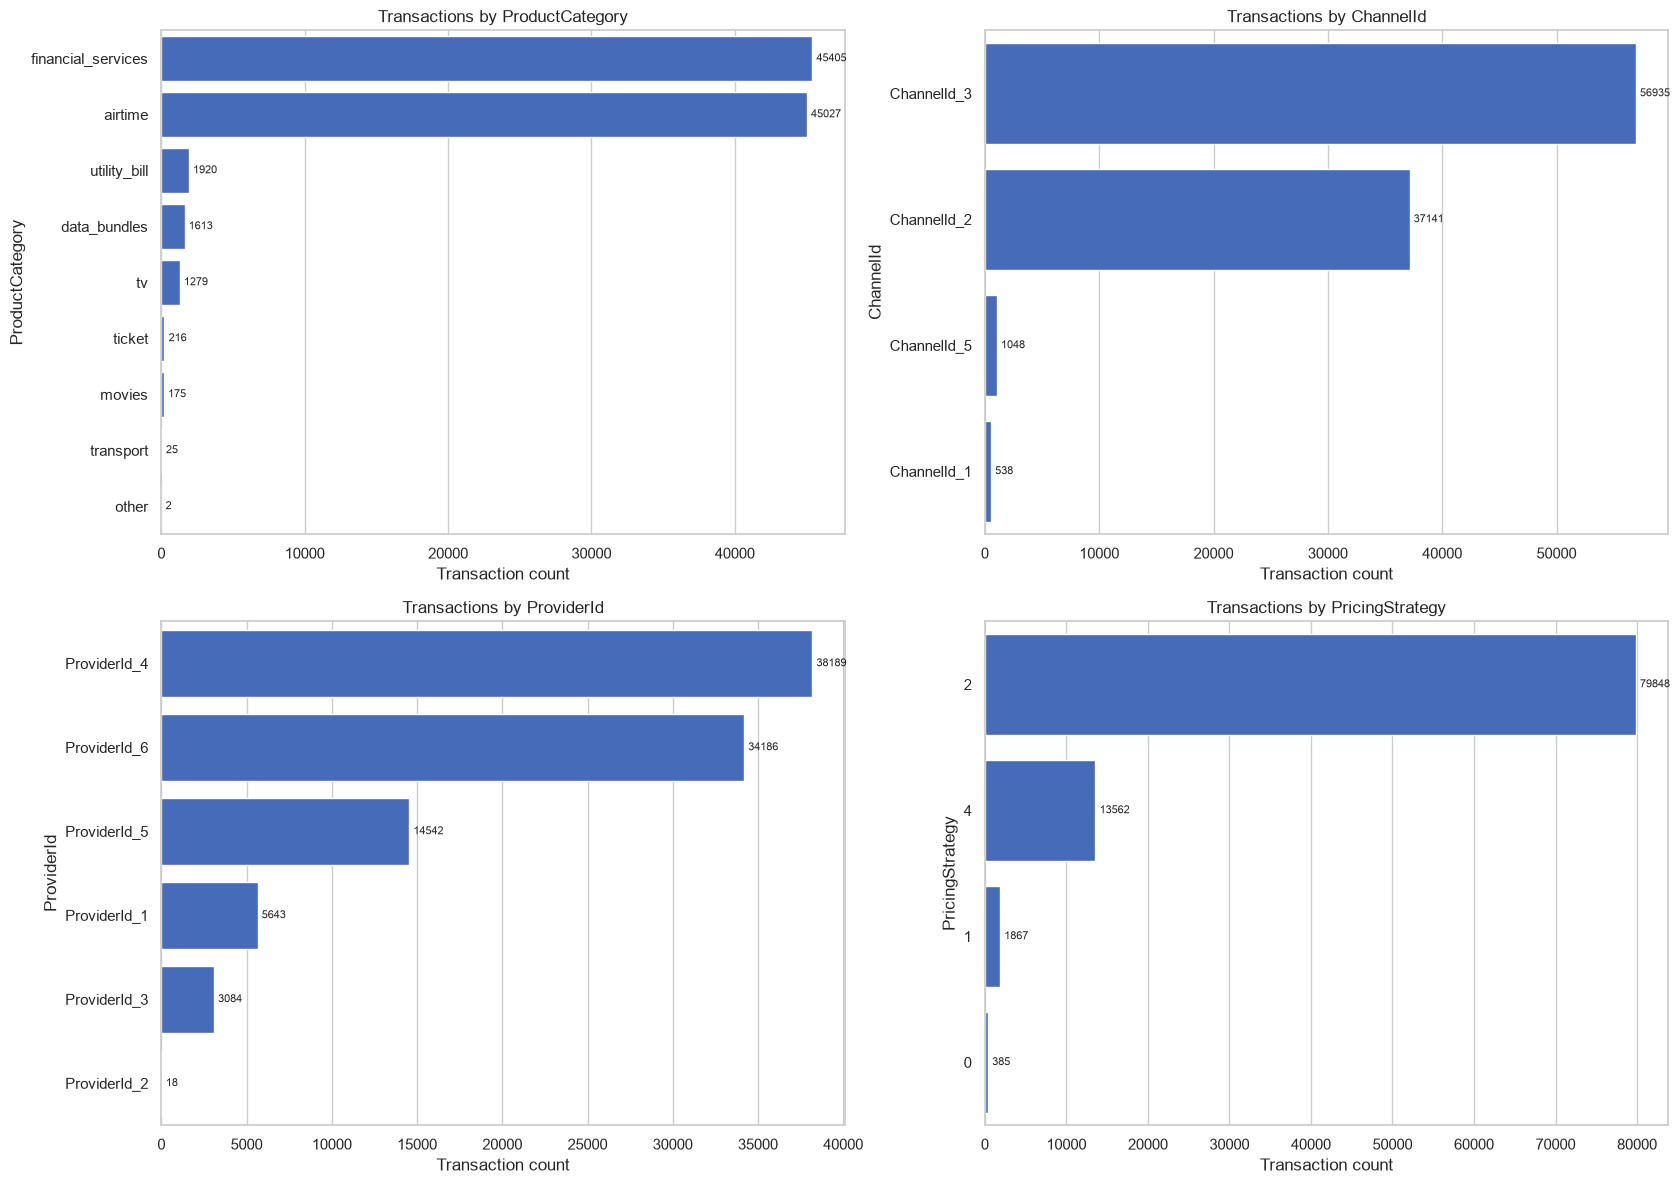

In [14]:
plot_columns = [
    "ProductCategory",
    "ChannelId",
    "ProviderId",
    "PricingStrategy",
]

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
axes = axes.flatten()

for axis, column in zip(axes, plot_columns):
    counts = eda_df[column].value_counts().head(12)

    sns.barplot(
        x=counts.values,
        y=counts.index.astype(str),
        ax=axis,
        color="#3366CC",
    )

    axis.set_title(f"Transactions by {column}")
    axis.set_xlabel("Transaction count")
    axis.set_ylabel(column)

    for container in axis.containers:
        axis.bar_label(container, fmt="%d", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

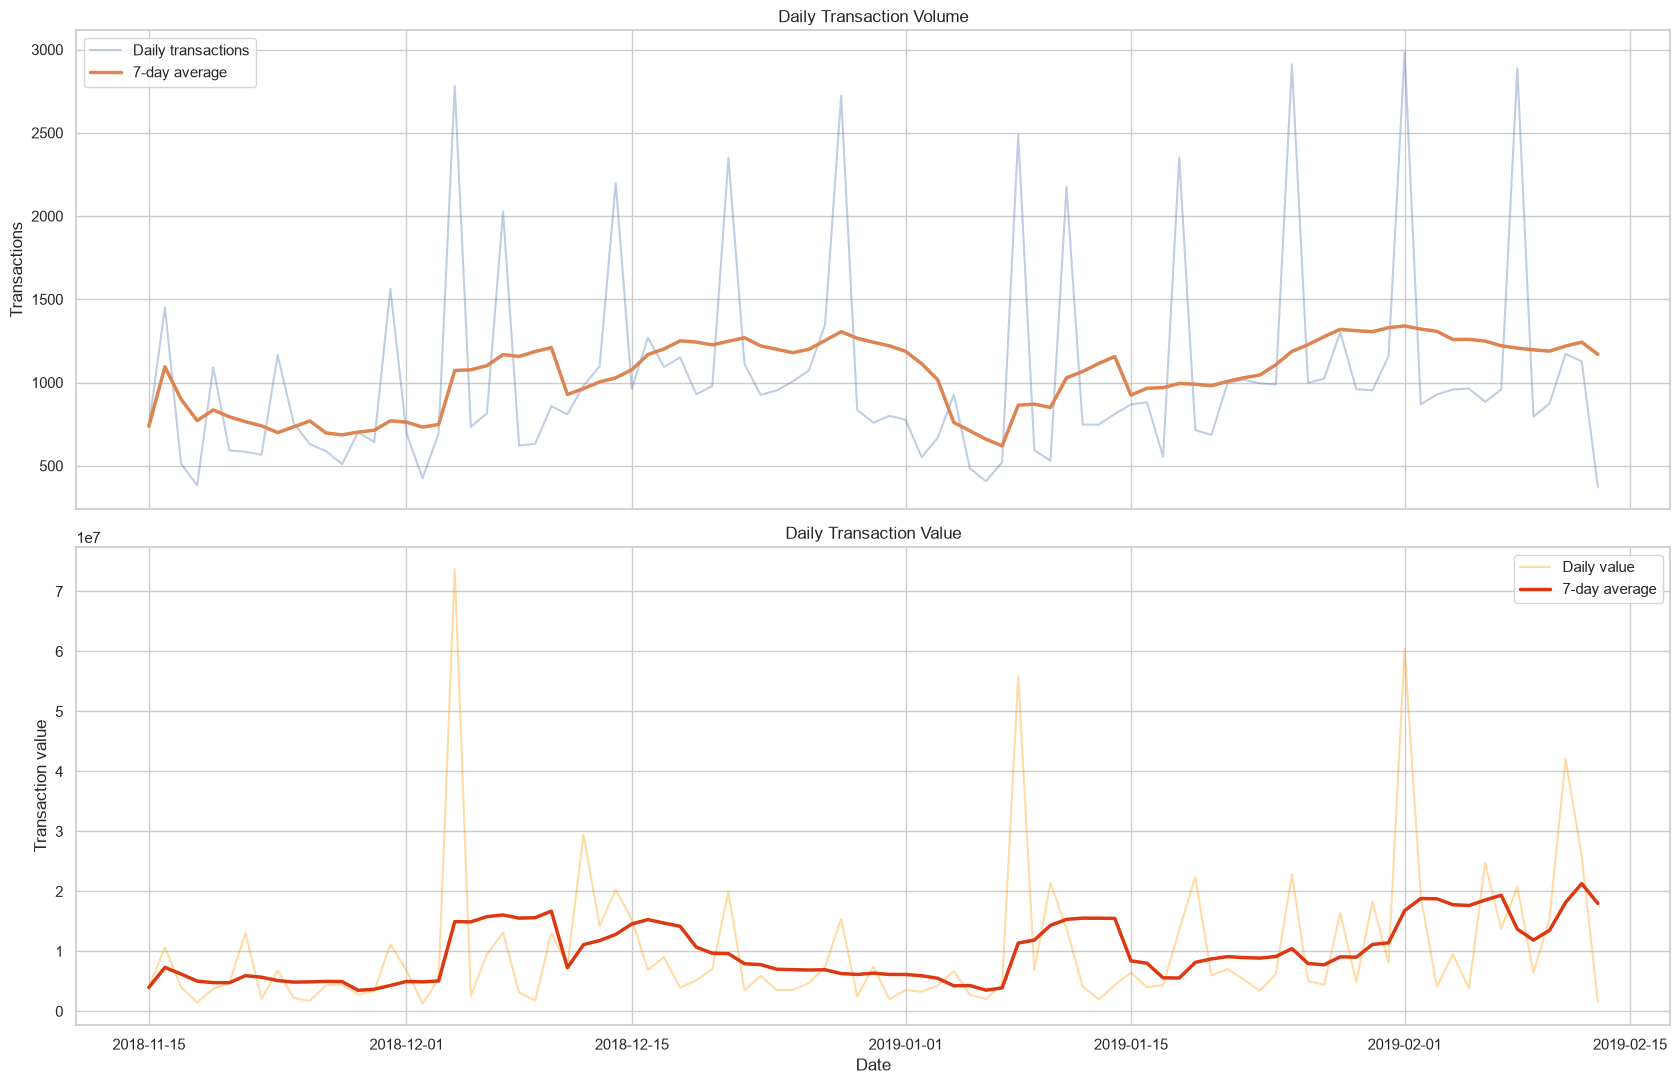

In [15]:
daily_activity = (
    eda_df.groupby("transaction_date")
    .agg(
        transaction_count=("TransactionId", "count"),
        total_value=("Value", "sum"),
        unique_customers=("CustomerId", "nunique"),
    )
    .reset_index()
)

daily_activity["transaction_date"] = pd.to_datetime(
    daily_activity["transaction_date"]
)

daily_activity["transaction_count_7d_average"] = (
    daily_activity["transaction_count"]
    .rolling(7, min_periods=1)
    .mean()
)

daily_activity["total_value_7d_average"] = (
    daily_activity["total_value"]
    .rolling(7, min_periods=1)
    .mean()
)

fig, axes = plt.subplots(2, 1, figsize=(17, 11), sharex=True)

axes[0].plot(
    daily_activity["transaction_date"],
    daily_activity["transaction_count"],
    alpha=0.35,
    label="Daily transactions",
)
axes[0].plot(
    daily_activity["transaction_date"],
    daily_activity["transaction_count_7d_average"],
    linewidth=2.5,
    label="7-day average",
)
axes[0].set_title("Daily Transaction Volume")
axes[0].set_ylabel("Transactions")
axes[0].legend()

axes[1].plot(
    daily_activity["transaction_date"],
    daily_activity["total_value"],
    alpha=0.35,
    color="#FF9900",
    label="Daily value",
)
axes[1].plot(
    daily_activity["transaction_date"],
    daily_activity["total_value_7d_average"],
    linewidth=2.5,
    color="#DC3912",
    label="7-day average",
)
axes[1].set_title("Daily Transaction Value")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Transaction value")
axes[1].legend()

plt.tight_layout()
plt.show()

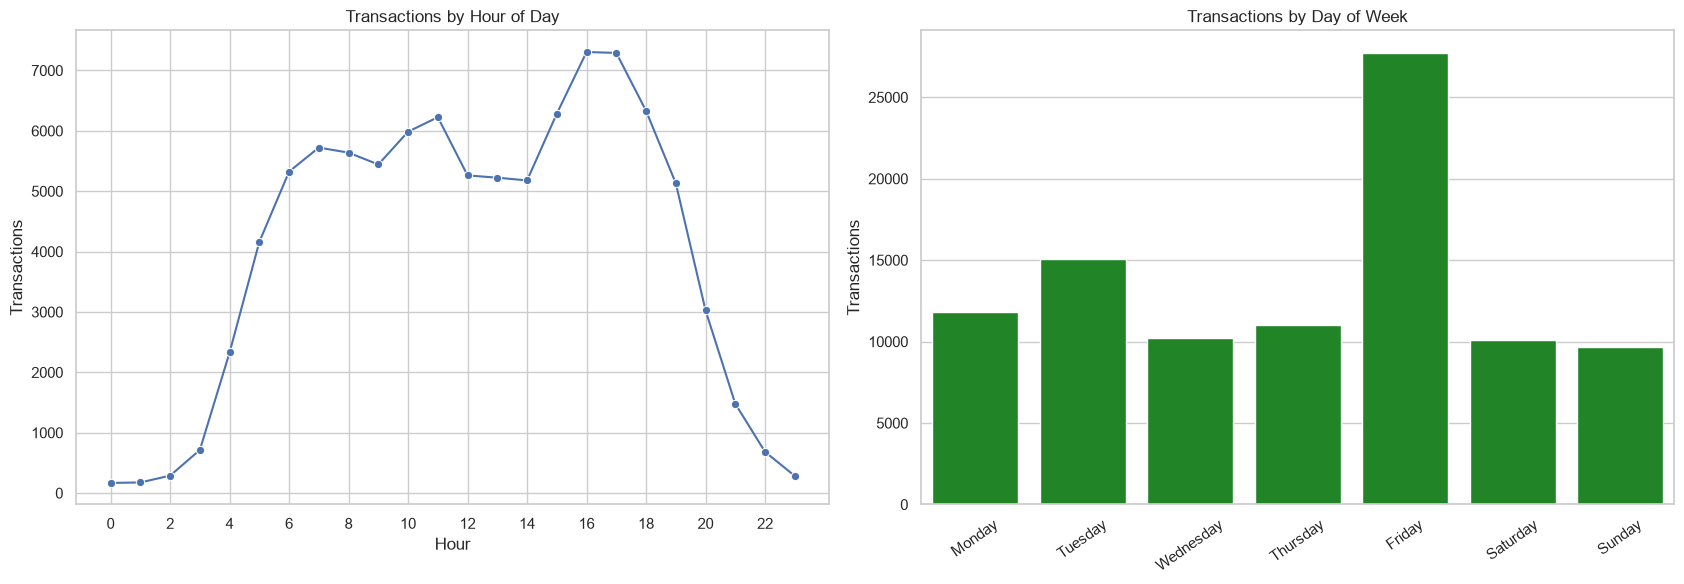

In [16]:
hourly_activity = (
    eda_df.groupby("transaction_hour")
    .agg(
        transaction_count=("TransactionId", "count"),
        total_value=("Value", "sum"),
        unique_customers=("CustomerId", "nunique"),
    )
    .reset_index()
)

weekday_activity = (
    eda_df.groupby("transaction_weekday")
    .agg(
        transaction_count=("TransactionId", "count"),
        total_value=("Value", "sum"),
    )
    .reindex(weekday_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.lineplot(
    data=hourly_activity,
    x="transaction_hour",
    y="transaction_count",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Transactions by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Transactions")
axes[0].set_xticks(range(0, 24, 2))

sns.barplot(
    data=weekday_activity,
    x="transaction_weekday",
    y="transaction_count",
    ax=axes[1],
    color="#109618",
)
axes[1].set_title("Transactions by Day of Week")
axes[1].set_xlabel("")
axes[1].set_ylabel("Transactions")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In [17]:
customer_summary = (
    eda_df.groupby("CustomerId")
    .agg(
        transaction_count=("TransactionId", "count"),
        total_transaction_value=("Value", "sum"),
        average_transaction_value=("Value", "mean"),
        transaction_value_std=("Value", "std"),
        debit_transaction_count=("is_debit", "sum"),
        active_days=("transaction_date", "nunique"),
        first_transaction=("TransactionStartTime", "min"),
        last_transaction=("TransactionStartTime", "max"),
    )
    .reset_index()
)

customer_summary["transaction_value_std"] = (
    customer_summary["transaction_value_std"].fillna(0)
)

customer_summary["debit_percentage"] = (
    customer_summary["debit_transaction_count"]
    .div(customer_summary["transaction_count"])
    .mul(100)
)

customer_summary["active_span_days"] = (
    customer_summary["last_transaction"]
    - customer_summary["first_transaction"]
).dt.days

display(customer_summary.describe().T)

,count,mean,std,min,25%,50%,75%,max
transaction_count,"3,742.0000",25.5644,96.9296,1.0000,2.0000,7.0000,20.0000,"4,091.0000"
total_transaction_value,"3,742.0000","253,102.5283","2,715,876.8094",50.0000,"6,500.0000","32,000.0000","102,060.0000","104,900,000.0000"
average_transaction_value,"3,742.0000","18,756.1165","167,452.8909",50.0000,"1,160.6551","3,950.0000","7,096.0395","8,601,821.1429"
transaction_value_std,"3,742.0000","12,744.1957","96,921.1779",0.0000,369.5603,"2,799.2355","4,253.9727","3,309,916.1236"
debit_transaction_count,"3,742.0000",10.2055,73.1716,0.0000,0.0000,3.0000,7.0000,"4,091.0000"
active_days,"3,742.0000",5.8450,9.2641,1.0000,1.0000,2.0000,6.0000,71.0000
debit_percentage,"3,742.0000",30.2990,22.9424,0.0000,0.0000,33.3333,42.8571,100.0000
active_span_days,"3,742.0000",18.9604,26.8717,0.0000,0.0000,3.0000,32.0000,90.0000


In [18]:
ranked_customers = customer_summary.sort_values(
    "transaction_count",
    ascending=False,
).copy()

ranked_customers["cumulative_transaction_percentage"] = (
    ranked_customers["transaction_count"]
    .cumsum()
    .div(ranked_customers["transaction_count"].sum())
    .mul(100)
)

top_1_percent_count = max(
    1,
    int(np.ceil(len(ranked_customers) * 0.01)),
)

top_10_percent_count = max(
    1,
    int(np.ceil(len(ranked_customers) * 0.10)),
)

top_1_share = (
    ranked_customers.head(top_1_percent_count)["transaction_count"].sum()
    / ranked_customers["transaction_count"].sum()
    * 100
)

top_10_share = (
    ranked_customers.head(top_10_percent_count)["transaction_count"].sum()
    / ranked_customers["transaction_count"].sum()
    * 100
)

print("CUSTOMER CONCENTRATION")
print("-" * 60)
print(f"Customers: {len(ranked_customers):,}")
print(f"Top 1% transaction share: {top_1_share:.2f}%")
print(f"Top 10% transaction share: {top_10_share:.2f}%")
print(
    "Largest customer transaction count: "
    f"{ranked_customers['transaction_count'].max():,}"
)

display(
    ranked_customers[
        [
            "CustomerId",
            "transaction_count",
            "total_transaction_value",
            "active_days",
            "cumulative_transaction_percentage",
        ]
    ].head(10)
)

CUSTOMER CONCENTRATION
------------------------------------------------------------
Customers: 3,742
Top 1% transaction share: 24.35%
Top 10% transaction share: 62.94%
Largest customer transaction count: 4,091


,CustomerId,transaction_count,total_transaction_value,active_days,cumulative_transaction_percentage
3478,CustomerId_7343,4091,104900000,11,4.2765
1969,CustomerId_3634,2085,2726207,20,6.4561
3390,CustomerId_647,1869,3905264,71,8.4098
66,CustomerId_1096,784,2041334,12,9.2294
2271,CustomerId_4033,778,1927834,58,10.0427
1494,CustomerId_3066,612,1171282,57,10.6824
1072,CustomerId_2528,610,1868148,19,11.3201
1224,CustomerId_2728,586,1340378,69,11.9326
1504,CustomerId_3078,573,2541260,22,12.5316
3605,CustomerId_806,557,2097380,30,13.1139


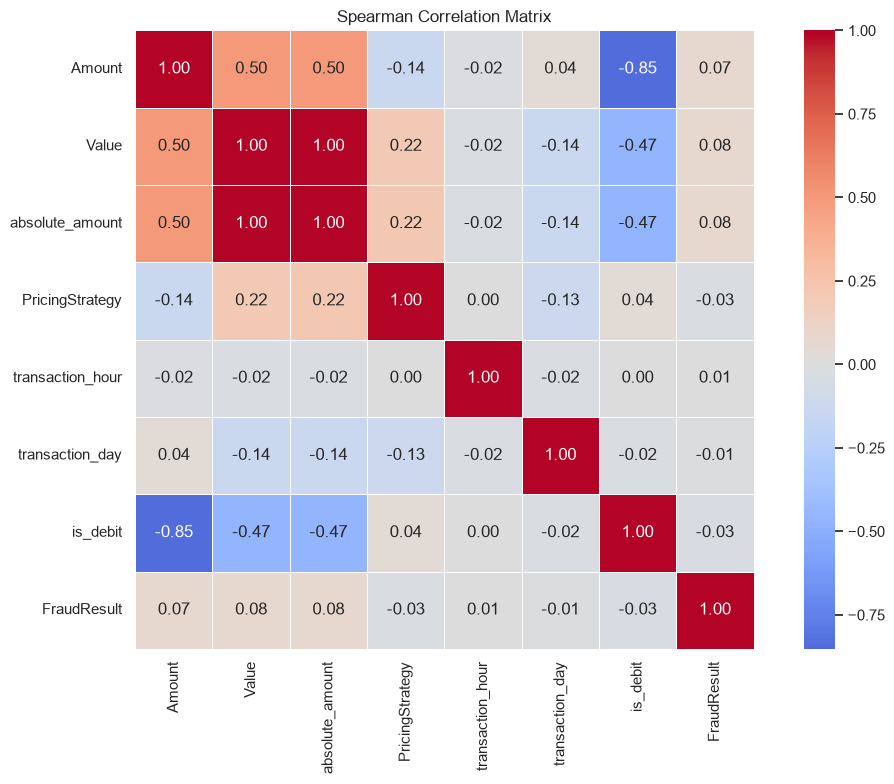

,Amount,Value,absolute_amount,PricingStrategy,transaction_hour,transaction_day,is_debit,FraudResult
Amount,1.0000,0.4974,0.4966,-0.1407,-0.0167,0.0426,-0.8516,0.0735
Value,0.4974,1.0000,0.9997,0.2174,-0.0206,-0.1421,-0.4665,0.0770
absolute_amount,0.4966,0.9997,1.0000,0.2191,-0.0210,-0.1426,-0.4658,0.0771
PricingStrategy,-0.1407,0.2174,0.2191,1.0000,0.0050,-0.1282,0.0412,-0.0311
transaction_hour,-0.0167,-0.0206,-0.0210,0.0050,1.0000,-0.0204,0.0034,0.0082
transaction_day,0.0426,-0.1421,-0.1426,-0.1282,-0.0204,1.0000,-0.0228,-0.0086
is_debit,-0.8516,-0.4665,-0.4658,0.0412,0.0034,-0.0228,1.0000,-0.0343
FraudResult,0.0735,0.0770,0.0771,-0.0311,0.0082,-0.0086,-0.0343,1.0000


In [19]:
correlation_df = eda_df[
    [
        "Amount",
        "Value",
        "absolute_amount",
        "PricingStrategy",
        "transaction_hour",
        "transaction_day",
        "is_debit",
        "FraudResult",
    ]
].copy()

correlation_matrix = correlation_df.corr(method="spearman")

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

display(correlation_matrix.round(4))

In [20]:
def iqr_outlier_summary(
    data: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    records = []

    for column in columns:
        first_quartile = data[column].quantile(0.25)
        third_quartile = data[column].quantile(0.75)
        iqr = third_quartile - first_quartile

        lower_bound = first_quartile - (1.5 * iqr)
        upper_bound = third_quartile + (1.5 * iqr)

        outlier_mask = (
            (data[column] < lower_bound)
            | (data[column] > upper_bound)
        )

        records.append(
            {
                "feature": column,
                "q1": first_quartile,
                "q3": third_quartile,
                "iqr": iqr,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "outlier_count": int(outlier_mask.sum()),
                "outlier_percentage": outlier_mask.mean() * 100,
            }
        )

    return pd.DataFrame(records)


outlier_summary = iqr_outlier_summary(
    eda_df,
    ["Amount", "absolute_amount", "Value"],
)

display(outlier_summary.round(4))

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,Amount,-50.0000,"2,800.0000","2,850.0000","-4,325.0000","7,075.0000",24441,25.5493
1,absolute_amount,275.0000,"5,000.0000","4,725.0000","-6,812.5000","12,087.5000",8910,9.3140
2,Value,275.0000,"5,000.0000","4,725.0000","-6,812.5000","12,087.5000",9021,9.4301


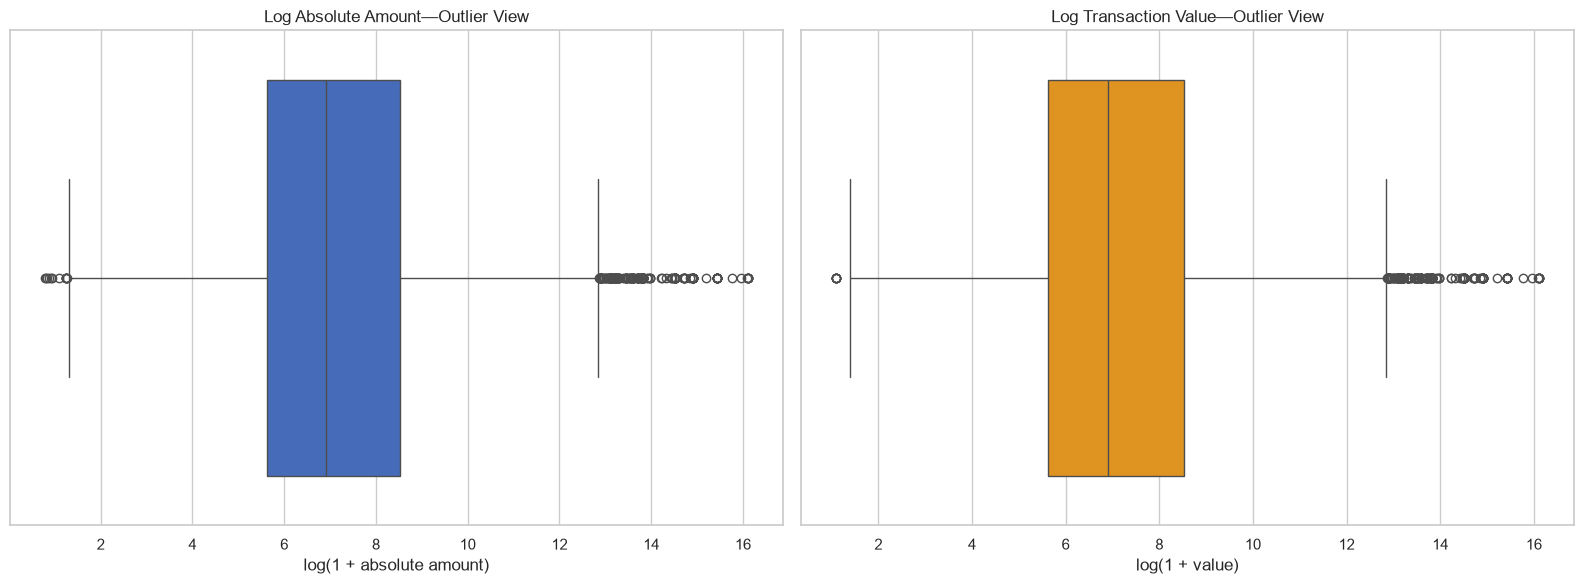

In [21]:
figure, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    x=np.log1p(eda_df["absolute_amount"]),
    ax=axes[0],
    color="#3366CC",
)
axes[0].set_title("Log Absolute Amount—Outlier View")
axes[0].set_xlabel("log(1 + absolute amount)")

sns.boxplot(
    x=np.log1p(eda_df["Value"]),
    ax=axes[1],
    color="#FF9900",
)
axes[1].set_title("Log Transaction Value—Outlier View")
axes[1].set_xlabel("log(1 + value)")

plt.tight_layout()
plt.show()

In [22]:
eda_df["amount_value_difference"] = (
    eda_df["absolute_amount"] - eda_df["Value"]
)

eda_df["amount_value_match"] = np.isclose(
    eda_df["absolute_amount"],
    eda_df["Value"],
    equal_nan=True,
)

mismatch_df = eda_df.loc[~eda_df["amount_value_match"]].copy()

mismatch_summary = (
    mismatch_df.groupby("ProductCategory")
    .agg(
        mismatch_count=("TransactionId", "count"),
        mean_absolute_amount=("absolute_amount", "mean"),
        mean_value=("Value", "mean"),
        median_difference=("amount_value_difference", "median"),
    )
    .sort_values("mismatch_count", ascending=False)
    .reset_index()
)

mismatch_summary["mismatch_percentage"] = (
    mismatch_summary["mismatch_count"]
    .div(len(mismatch_df))
    .mul(100)
)

print("AMOUNT–VALUE MISMATCH ANALYSIS")
print("-" * 70)
print(f"Mismatch rows: {len(mismatch_df):,}")
print(f"Mismatch percentage: {len(mismatch_df) / len(eda_df) * 100:.2f}%")

display(mismatch_summary.round(4))
display(
    mismatch_df[
        [
            "TransactionId",
            "ProductCategory",
            "Amount",
            "Value",
            "amount_value_difference",
        ]
    ].head(15)
)

AMOUNT–VALUE MISMATCH ANALYSIS
----------------------------------------------------------------------
Mismatch rows: 2,565
Mismatch percentage: 2.68%


,ProductCategory,mismatch_count,mean_absolute_amount,mean_value,median_difference,mismatch_percentage
0,utility_bill,1915,"19,170.3849","20,899.7645","-1,200.0000",74.6589
1,financial_services,328,100.9924,101.5030,-0.5000,12.7875
2,movies,174,"7,893.6782","10,993.6782","-2,000.0000",6.7836
3,tv,148,"69,253.3784","71,330.9797",-840.0000,5.7700


,TransactionId,ProductCategory,Amount,Value,amount_value_difference
3,TransactionId_380,utility_bill,"20,000.0000",21800,"-1,800.0000"
34,TransactionId_10285,financial_services,-67.2500,68,-0.7500
41,TransactionId_34855,utility_bill,"10,000.0000",11200,"-1,200.0000"
48,TransactionId_86046,utility_bill,"5,000.0000",5750,-750.0000
67,TransactionId_26794,utility_bill,"5,000.0000",5750,-750.0000
160,TransactionId_38708,utility_bill,500.0000,1115,-615.0000
171,TransactionId_83061,movies,"5,000.0000",7000,"-2,000.0000"
235,TransactionId_50696,utility_bill,"17,000.0000",18710,"-1,710.0000"
239,TransactionId_124238,financial_services,-35.6000,36,-0.4000
445,TransactionId_83961,utility_bill,"18,500.0000",20255,"-1,755.0000"


In [23]:
fraud_summary = (
    eda_df.groupby("FraudResult")
    .agg(
        transaction_count=("TransactionId", "count"),
        total_value=("Value", "sum"),
        mean_value=("Value", "mean"),
        median_value=("Value", "median"),
        unique_customers=("CustomerId", "nunique"),
    )
    .reset_index()
)

fraud_summary["transaction_percentage"] = (
    fraud_summary["transaction_count"]
    .div(len(eda_df))
    .mul(100)
)

display(fraud_summary.round(4))

fraud_rate = eda_df["FraudResult"].mean() * 100
print(f"FraudResult rate: {fraud_rate:.4f}%")
print(
    "FraudResult is retained for contextual analysis only; "
    "it is not treated as a credit-default target."
)

,FraudResult,transaction_count,total_value,mean_value,median_value,unique_customers,transaction_percentage
0,0,95469,645678490,"6,763.2267","1,000.0000",3731,99.7982
1,1,193,301431171,"1,561,819.5389","650,000.0000",54,0.2018


FraudResult rate: 0.2018%
FraudResult is retained for contextual analysis only; it is not treated as a credit-default target.


In [24]:
missing_percentage = (
    eda_df.isna().sum().sum()
    / eda_df.size
    * 100
)

print("TASK 2 EDA VALIDATION")
print("-" * 72)
print(f"Transactions analyzed: {len(eda_df):,}")
print(f"Customers analyzed: {eda_df['CustomerId'].nunique():,}")
print(f"Date coverage: {eda_df['TransactionStartTime'].min().date()} "
      f"to {eda_df['TransactionStartTime'].max().date()}")
print(f"Missing-value percentage: {missing_percentage:.4f}%")
print(f"Duplicate transaction IDs: "
      f"{eda_df['TransactionId'].duplicated().sum():,}")
print(f"Negative-amount percentage: "
      f"{eda_df['Amount'].lt(0).mean() * 100:.2f}%")
print(f"Amount–Value mismatch percentage: "
      f"{(~eda_df['amount_value_match']).mean() * 100:.2f}%")
print(f"FraudResult rate: {eda_df['FraudResult'].mean() * 100:.4f}%")
print(f"Top 1% customer transaction share: {top_1_share:.2f}%")
print(f"Top 10% customer transaction share: {top_10_share:.2f}%")
print("Required EDA components completed: True")

TASK 2 EDA VALIDATION
------------------------------------------------------------------------
Transactions analyzed: 95,662
Customers analyzed: 3,742
Date coverage: 2018-11-15 to 2019-02-13
Missing-value percentage: 0.0000%
Duplicate transaction IDs: 0
Negative-amount percentage: 39.92%
Amount–Value mismatch percentage: 2.68%
FraudResult rate: 0.2018%
Top 1% customer transaction share: 24.35%
Top 10% customer transaction share: 62.94%
Required EDA components completed: True
